# Walmart Sales Data Analysis
### End-to-End SQL + Python Project

**Tools:** Python (pandas, matplotlib, seaborn) · SQLite · Colab  
**Dataset:** 10,000 Walmart transactions across 100 branches in Texas (2019–2023)

This project analyzes Walmart sales data to uncover trends in branch performance, product profitability,
payment behaviour, and customer ratings — using SQL for business questions and Python for
statistical analysis and visualization.

## 1. Setup
Import libraries and initialise an in-memory SQLite database.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
conn = sqlite3.connect(':memory:')


## 2. Data Loading & Exploration
Load the dataset and run initial checks on shape, column types, and value ranges.

In [2]:
path = 'https://docs.google.com/spreadsheets/d/1wEPGbYoybguiV03b_H616ErJm2lWFNDDDCwfxB3BuO0/export?format=csv&gid=457885869'

df = pd.read_csv(path)
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [3]:
df.describe()

,invoice_id,quantity,rating,profit_margin
count,10051.000000,10020.000000,10051.000000,10051.000000
mean,5025.741220,2.353493,5.825659,0.393791
std,2901.174372,1.602658,1.763991,0.090669
min,1.000000,1.000000,3.000000,0.180000
25%,2513.500000,1.000000,4.000000,0.330000
50%,5026.000000,2.000000,6.000000,0.330000
75%,7538.500000,3.000000,7.000000,0.480000
max,10000.000000,10.000000,10.000000,0.570000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


## 3. Data Cleaning
Check for duplicates, null values, and fix column types before analysis.

In [5]:
df.duplicated().sum()

np.int64(51)

In [6]:
df.drop_duplicates(inplace=True)

**Result:** 51 duplicate rows found and removed, leaving 10,000 clean records.

In [7]:
df.isnull().sum()

,0
invoice_id,0
Branch,0
City,0
category,0
unit_price,31
quantity,31
date,0
time,0
payment_method,0
rating,0


In [8]:
df.shape

(10000, 11)

31 null values in `unit_price` and `quantity` — same rows missing both fields, likely a POS entry failure.
Dropped as they represent only 0.31% of records.

In [9]:
df.dropna(inplace=True)
df.isnull().sum()

,0
invoice_id,0
Branch,0
City,0
category,0
unit_price,0
quantity,0
date,0
time,0
payment_method,0
rating,0


## 4. Feature Engineering
- Strip `$` from `unit_price` and convert to float
- Calculate `total` (unit_price × quantity)
- Extract `year`, `day_of_week`, and `shift` from date/time columns
- Lowercase all column names

> SQLite doesn't support MySQL date functions like `YEAR()` or `HOUR()`, so temporal features
> are handled in pandas before loading.

In [10]:
df['unit_price'] = df['unit_price'].str.replace('$', '').astype(float)

In [11]:
df['total']=df['unit_price'] * df['quantity']


In [12]:
df.columns=df.columns.str.lower()

In [13]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.day_name()
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['shift'] = pd.cut(df['time'].dt.hour,
                     bins=[0, 12, 17, 24],
                     labels=['Morning', 'Afternoon', 'Evening'],
                     right=False)
df.head()

/tmp/ipykernel_5636/359165410.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


,invoice_id,branch,city,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,total,year,day_of_week,shift
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,2019-01-05,1900-01-01 13:08:00,Ewallet,9.1,0.48,522.83,2019,Saturday,Afternoon
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,2019-03-08,1900-01-01 10:29:00,Cash,9.6,0.48,76.40,2019,Friday,Morning
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,2019-03-03,1900-01-01 13:23:00,Credit card,7.4,0.33,324.31,2019,Sunday,Afternoon
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,2019-01-27,1900-01-01 20:33:00,Ewallet,8.4,0.33,465.76,2019,Sunday,Evening
4,5,WALM013,Irving,Sports and travel,86.31,7.0,2019-02-08,1900-01-01 10:37:00,Ewallet,5.3,0.48,604.17,2019,Friday,Morning


## 5. Load into SQLite
Push the cleaned dataframe into SQLite as a table called `walmart`.

In [14]:
df.to_sql('walmart', conn, index=False)

9969

---
## 6. SQL Analysis

11 business questions using CTEs, window functions, and aggregations.

---

### Q1 — Payment Method Breakdown
How many transactions and units were sold per payment method?

In [16]:
pd.read_sql_query("""
SELECT
	payment_method,
  COUNT(*) as number_of_payments,
  SUM(quantity) as number_quantity
FROM walmart
GROUP BY payment_method; """,conn)

,payment_method,number_of_payments,number_quantity
0,Cash,1832,4984.0
1,Credit card,4256,9567.0
2,Ewallet,3881,8932.0


**Finding:** Credit card leads at 43% of transactions, Ewallet at 39%, Cash at 18%.
Digital payments make up 82% of volume.

### Q2 — Highest-Rated Category per Branch
Which product category has the highest average rating in each branch?  
*Uses a two-CTE approach with `RANK()` partitioned by branch.*

In [17]:
pd.read_sql_query("""
with a as
(select branch, category, avg(rating) as avg_rating
from walmart
group by branch, category),
b as
(select branch, category, avg_rating,
rank() over (partition by branch order by avg_rating desc) as ranking
from a)
select branch, category, avg_rating, ranking
from b
where ranking = 1
""", conn)

,branch,category,avg_rating,ranking
0,WALM001,Electronic accessories,7.450000,1
1,WALM002,Food and beverages,8.250000,1
2,WALM003,Sports and travel,7.500000,1
3,WALM004,Food and beverages,9.300000,1
4,WALM005,Health and beauty,8.366667,1
...,...,...,...,...
96,WALM096,Sports and travel,9.600000,1
97,WALM097,Food and beverages,7.675000,1
98,WALM098,Health and beauty,9.800000,1
99,WALM099,Electronic accessories,5.950000,1


**Finding:** No single category dominates chain-wide — top-rated categories vary by branch,
suggesting localised customer preferences.

### Q3 — Busiest Day per Branch
What is the highest-transaction day of the week for each branch?

In [18]:
pd.read_sql_query("""
with a as
(select branch, day_of_week, count(*) as number_transactions
from walmart
group by branch, day_of_week),
b as
(select branch, day_of_week, number_transactions,
rank() over (partition by branch order by number_transactions desc) as ranking
from a)
select branch, day_of_week, number_transactions, ranking
from b
where ranking = 1
""", conn)




,branch,day_of_week,number_transactions,ranking
0,WALM001,Thursday,16,1
1,WALM002,Thursday,15,1
2,WALM003,Tuesday,33,1
3,WALM004,Sunday,14,1
4,WALM005,Wednesday,19,1
...,...,...,...,...
109,WALM096,Tuesday,15,1
110,WALM097,Friday,12,1
111,WALM098,Monday,18,1
112,WALM099,Sunday,30,1


**Finding:** Peak days differ across branches — a uniform chain-wide staffing schedule
would miss branch-specific demand patterns.

### Q4 — Category Ratings by City
Average, min, and max customer ratings for each category in each city.

In [19]:
pd.read_sql_query("""
SELECT
	city,
    category,
	AVG(rating) as average,
    MAX(rating) as max,
    MIN(rating) as min
FROM walmart
GROUP BY category, City;
""",conn)

,city,category,average,max,min
0,Abilene,Electronic accessories,7.966667,8.8,7.1
1,Alice,Electronic accessories,7.300000,7.3,7.3
2,Allen,Electronic accessories,6.400000,6.4,6.4
3,Amarillo,Electronic accessories,6.833333,7.8,5.2
4,Angleton,Electronic accessories,7.550000,10.0,5.1
...,...,...,...,...,...
508,Texas City,Sports and travel,5.500000,6.5,4.5
509,Waco,Sports and travel,5.600000,5.6,5.6
510,Waxahachie,Sports and travel,6.160000,7.4,5.2
511,Weatherford,Sports and travel,5.200000,6.2,4.2


**Finding:** Wide rating spreads (min 3.0, max 10.0) in most categories suggest
inconsistent customer experience within the same product type.

### Q5 — Total Profit by Category
Which categories generate the most profit overall?  
*Profit = profit_margin × total revenue per transaction.*

In [20]:
pd.read_sql_query("""
SELECT
	category,
	SUM(profit_margin*total) AS profit
FROM walmart
GROUP BY category
ORDER BY profit DESC
""",conn)

,category,profit
0,Fashion accessories,192314.8932
1,Home and lifestyle,192213.6381
2,Electronic accessories,30772.4895
3,Food and beverages,21552.8622
4,Sports and travel,20613.8082
5,Health and beauty,18671.7345


**Finding:** Fashion accessories ($192K) and Home and lifestyle ($192K) generate ~6x more profit
than any other category. The bottom three categories contribute under $22K each.

### Q6 — Most Common Payment Method per Branch
What payment method is used most at each branch?

In [21]:
pd.read_sql_query("""
with a as
(select branch, payment_method, count(*) as number_payments
from walmart
group by branch, payment_method),
b as (select branch, payment_method, number_payments, rank() over (partition by branch order by number_payments desc) as ranking
from a)
select branch, payment_method, number_payments, ranking
from b
where ranking = 1
""", conn)


,branch,payment_method,number_payments,ranking
0,WALM001,Ewallet,45,1
1,WALM002,Ewallet,37,1
2,WALM003,Credit card,115,1
3,WALM004,Ewallet,44,1
4,WALM005,Ewallet,56,1
...,...,...,...,...
95,WALM096,Ewallet,50,1
96,WALM097,Ewallet,38,1
97,WALM098,Ewallet,44,1
98,WALM099,Credit card,83,1


**Finding:** Ewallet is the top method in the majority of branches. A small number of outlier
branches heavily favour Credit card — worth investigating for demographic or infrastructure reasons.

### Q7 — Transactions by Shift
How are transactions distributed across Morning, Afternoon, and Evening shifts per branch?

In [22]:
pd.read_sql_query("""
SELECT branch, shift, COUNT(*) as total_transactions
FROM walmart
GROUP BY branch, shift
ORDER BY branch, total_transactions DESC
""",conn)

,branch,shift,total_transactions
0,WALM001,Evening,39
1,WALM001,Afternoon,27
2,WALM001,Morning,8
3,WALM002,Evening,27
4,WALM002,Afternoon,23
...,...,...,...
295,WALM099,Evening,42
296,WALM099,Morning,40
297,WALM100,Evening,27
298,WALM100,Morning,19


**Finding:** Evening and Afternoon shifts generally see more activity than Morning,
though this varies by branch.

### Q8 — Branches with Largest Revenue Decline (2022 → 2023)
Which 5 branches had the highest revenue drop year-over-year?  
*Two CTEs calculate per-branch revenue for each year, then a JOIN computes the decline ratio.*

In [23]:
## rdr == last_rev-cur_rev/last_rev*100
pd.read_sql_query("""
WITH revenue2022 AS
(
SELECT
	branch,
	SUM(total) AS revenue
FROM walmart
WHERE year =2022
GROUP BY branch
),
revenue2023
AS
(
SELECT
	branch,
	SUM(total) AS revenue
FROM walmart
WHERE year =2023
GROUP BY branch
)
SELECT
	ls.branch,
    ls.revenue as last_revenue,
    cs.revenue as cur_revenue,
   ROUND( (ls.revenue-cs.revenue)/ls.revenue*100,2) as rev_decrease_ratio
FROM revenue2022 AS ls
JOIN
revenue2023 as cs
ON ls.branch=cs.branch
WHERE
	ls.revenue > cs.revenue
ORDER BY 4 DESC LIMIT 5
""",conn)


,branch,last_revenue,cur_revenue,rev_decrease_ratio
0,WALM045,1731.0,647.0,62.62
1,WALM047,2581.0,1069.0,58.58
2,WALM098,2446.0,1030.0,57.89
3,WALM033,2099.0,931.0,55.65
4,WALM081,1723.0,850.0,50.67


**Finding:** Revenue decline is branch-specific rather than chain-wide — pointing to local
operational or competitive factors. These 5 branches are the priority targets for further review.

### Q9 — Running Revenue Total by Branch
Cumulative revenue per branch across years, showing compounding performance over time.  
*Uses `SUM() OVER (PARTITION BY branch ORDER BY year)` to accumulate progressively.*

In [24]:
pd.read_sql_query("""
with a as
(select branch, year, sum(total) as revenue
from walmart
group by year, branch
order by branch, year)
select branch, year, revenue, sum(revenue) over (partition by branch order by year) as running_total
from a
""",conn)


,branch,year,revenue,running_total
0,WALM001,2019,3671.68,3671.68
1,WALM001,2020,1814.00,5485.68
2,WALM001,2021,1789.00,7274.68
3,WALM001,2022,1488.00,8762.68
4,WALM001,2023,1463.00,10225.68
...,...,...,...,...
495,WALM100,2019,3156.34,3156.34
496,WALM100,2020,1604.00,4760.34
497,WALM100,2021,772.00,5532.34
498,WALM100,2022,1156.00,6688.34


**Finding:** By 2023, the gap between top and bottom performing branches is significant —
early underperformance compounds over time.

### Q10 — Top 3 Profitable Categories per City
Which three categories generate the most profit in each city?

In [25]:
pd.read_sql_query("""
with a as
(select city, category, sum(profit_margin*total) as profit
from walmart
group by city, category),
b as
(select city, category, profit, rank() over (partition by city order by profit desc) as ranking
from a )
select city, category, profit, ranking
from b
where ranking <=3
""", conn)

,city,category,profit,ranking
0,Abilene,Fashion accessories,2306.9808,1
1,Abilene,Home and lifestyle,1661.8560,2
2,Abilene,Food and beverages,288.5664,3
3,Alamo,Home and lifestyle,1156.9338,1
4,Alamo,Fashion accessories,815.1297,2
...,...,...,...,...
289,Weatherford,Fashion accessories,1411.2540,2
290,Weatherford,Sports and travel,134.1000,3
291,Weslaco,Home and lifestyle,7086.3837,1
292,Weslaco,Fashion accessories,6144.0687,2


**Finding:** Fashion accessories and Home and lifestyle appear in the top 3 for most cities,
but some cities show meaningful local variation worth acting on.

### Q11 — Category Revenue Share per Branch (%)
What percentage of each branch's revenue comes from each category?  
*Uses `SUM() OVER (PARTITION BY branch)` to calculate the branch total without collapsing rows.*

In [26]:
pd.read_sql_query("""
with a as
(select branch, category, sum(total) as revenue
from walmart
group by branch, category),
b as (select branch, category, revenue, round(revenue/sum(revenue) over (partition by branch)*100,3) as percentage
from a)
select branch, category, revenue, percentage
from b
order by branch, percentage desc

""",conn)

,branch,category,revenue,percentage
0,WALM001,Home and lifestyle,4819.08,47.127
1,WALM001,Fashion accessories,2920.68,28.562
2,WALM001,Sports and travel,1516.29,14.828
3,WALM001,Electronic accessories,969.63,9.482
4,WALM002,Home and lifestyle,3108.09,40.187
...,...,...,...,...
517,WALM100,Home and lifestyle,3656.60,44.299
518,WALM100,Fashion accessories,2272.64,27.533
519,WALM100,Health and beauty,1366.71,16.557
520,WALM100,Sports and travel,497.41,6.026


**Finding:** Some branches are heavily concentrated in one or two categories —
a risk if those categories underperform seasonally or competitively.

---
## 7. Python Analysis

---

### Correlation — What Drives Revenue?
Which variables correlate most with transaction revenue?

###Correlation matrix — which variables correlate with revenue/total? Rating, quantity, unit price. Heatmap visual with seaborn

quantity      0.800156
unit_price    0.530603
rating        0.111130
dtype: float64


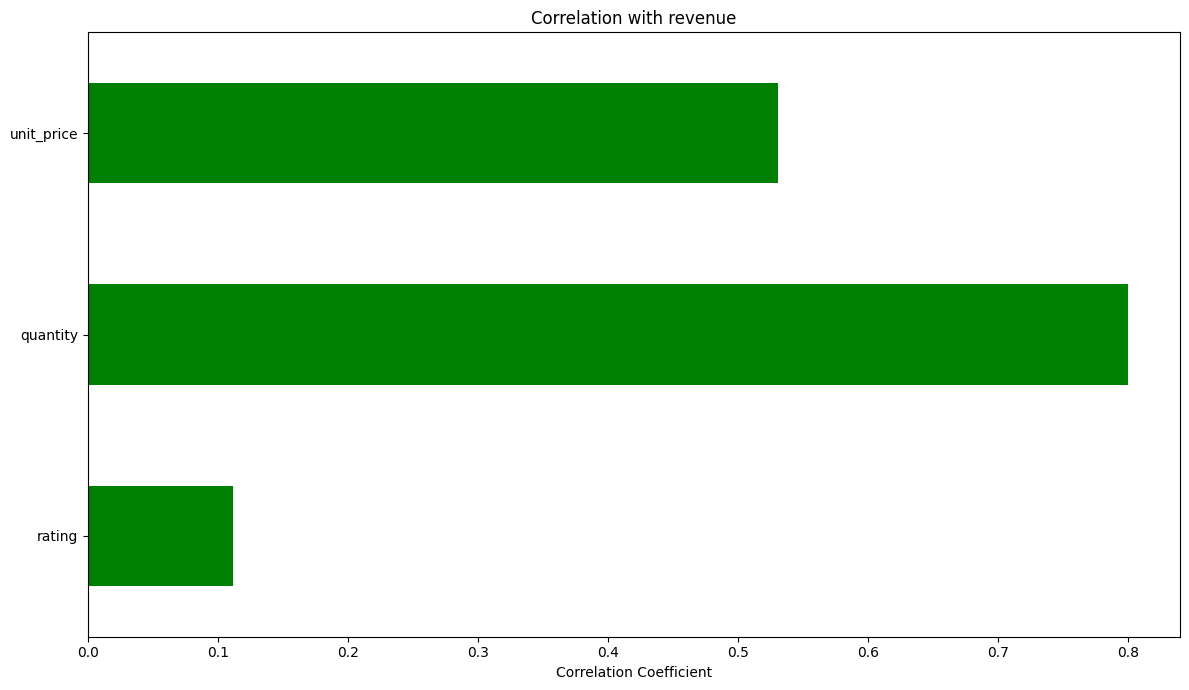

In [39]:
corr = df[['rating', 'quantity', 'unit_price']].corrwith(df['total'])
print(corr.sort_values(key=abs, ascending=False))

plt.figure(figsize=(12,7))
corr.plot(kind='barh', color=['red' if x < 0 else 'green' for x in corr])
plt.title('Correlation with revenue')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()



**Finding:** `quantity` is the strongest driver of revenue. `unit_price` also correlates positively.
`rating` shows near-zero correlation — customer satisfaction doesn't translate directly to higher spend.

### Rating vs. Revenue
Does a higher customer rating mean higher transaction value?

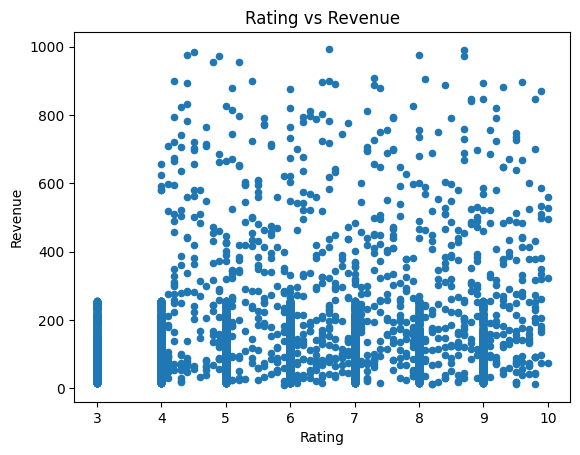

In [35]:
df.plot.scatter(x='rating', y = 'total')
plt.title('Rating vs Revenue')
plt.xlabel('Rating')
plt.ylabel('Revenue')
plt.show()

**Finding:** No clear relationship. High-value transactions receive low and high ratings equally —
ratings reflect experience quality, not spend level.

### Top 5 Branch Revenue Over Time (2019–2023)
Revenue trajectory for the 5 highest-earning branches.

###Branch revenue over time — line chart showing trajectory for each branch, this directly visualises the "decline" story from your Q8

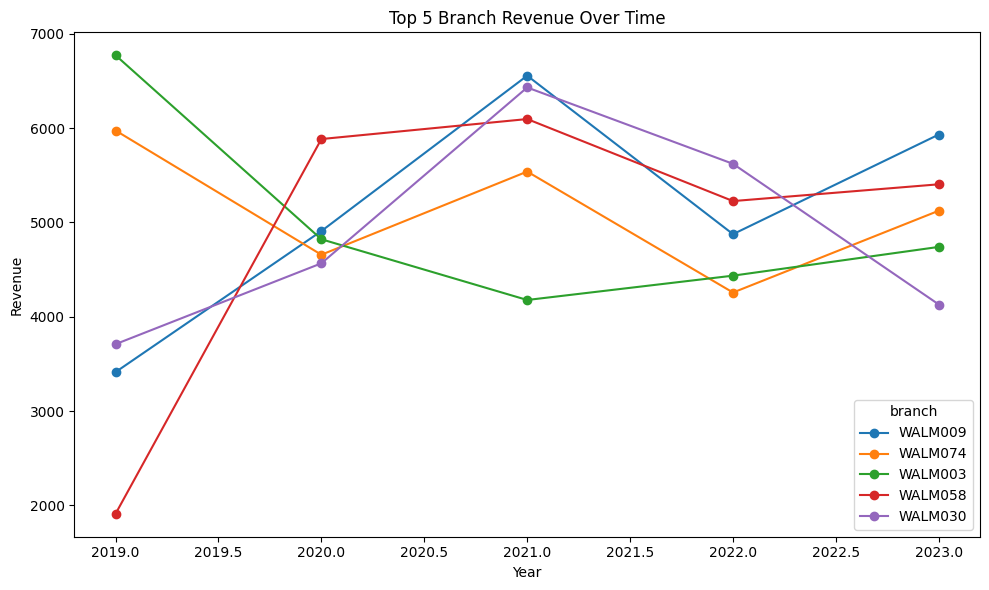

In [44]:
revenue_by_year = df.groupby(['year', 'branch'])['total'].sum().reset_index()
revenue_pivot = revenue_by_year.pivot(index='year', columns='branch', values='total')
top_branches = df.groupby('branch')['total'].sum().nlargest(5).index

revenue_pivot[top_branches].plot(kind='line', marker='o', figsize=(10,6))


plt.title('Top 5 Branch Revenue Over Time')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

---
## 8. Summary & Recommendations

**Key Findings:**
- Digital payments (Credit card + Ewallet) account for 82% of transactions
- Fashion accessories and Home and lifestyle drive the majority of total profit
- Customer ratings don't correlate with transaction revenue
- Revenue decline is concentrated in specific branches, not chain-wide
- Staffing needs vary significantly by branch — peak days and shifts differ

**Recommendations:**
1. Investigate the 5 highest-decline branches — cross-reference with ratings and payment data to find the cause
2. Prioritise top profit categories in underperforming branches
3. Build branch-specific staffing schedules based on Q3 and Q7 findings